In [1]:
import torch
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = ''.join(open('names.txt')).splitlines()

In [3]:
alpha = sorted(list(set(''.join(words).lower())))
stoi = {c: i+1 for i, c in enumerate(list(alpha))}
A = len(alpha) + 1
stoi['.'] = 0
itos = {v: k for k, v in stoi.items()}

In [4]:
random.shuffle(words)

In [5]:
N = torch.zeros((A,A), dtype = torch.int32)

In [6]:
for w in words:
    chars = ['.'] + list(w.lower()) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

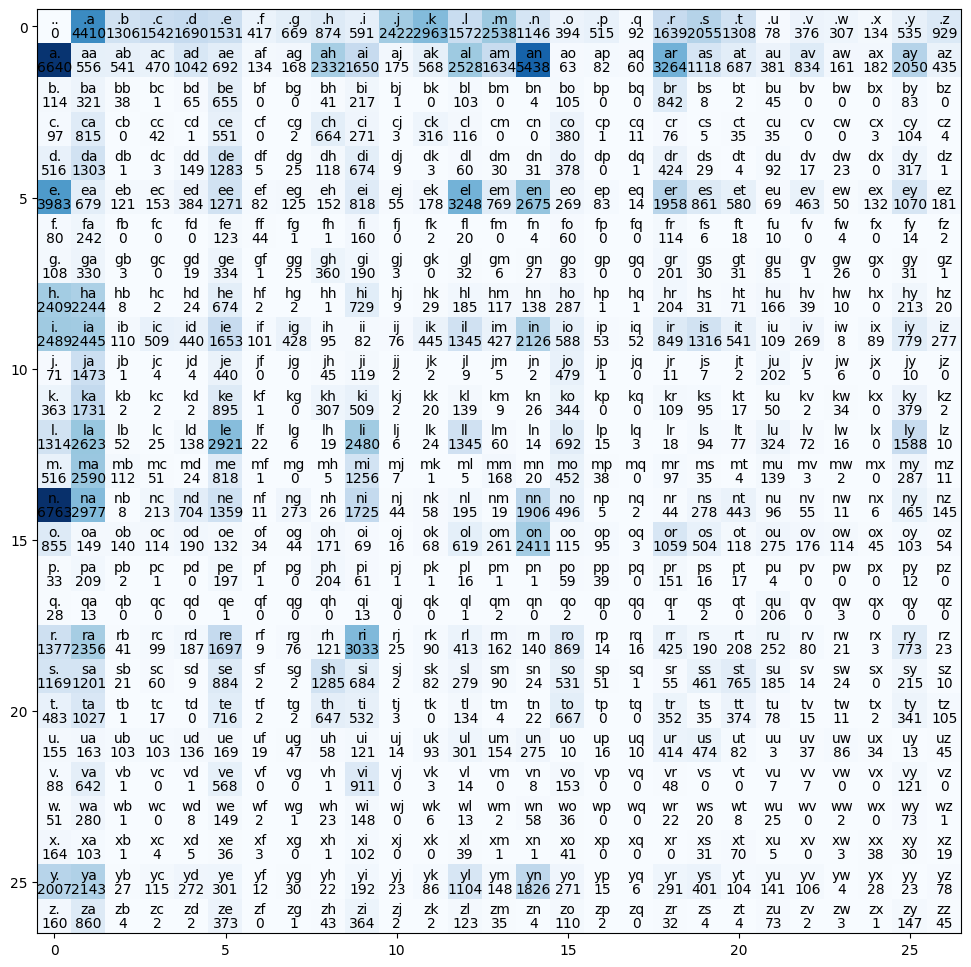

In [7]:
plt.figure(figsize=(12,12))
plt.imshow(N, cmap = 'Blues')
for i in range(A):
    for j in range(A):
        plt.text(j,i, itos[i]+itos[j], ha = 'center', va = 'bottom', color = 'black')
        plt.text(j,i, N[i, j].item(), ha = 'center', va = 'top', color = 'black')

In [12]:
P = (N + 1).float()
P = P / P.sum(1, keepdim = True)

In [13]:
gen = torch.Generator().manual_seed(42)
for i in range(10):
    ix = 0
    name = ''
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement = True, generator = gen).item()
        if ix == 0:
            break
        name += itos[ix]
    print(name)

anugeenvi
s
mabidushan
stan
silaylelaremah
li
le
epiachalen
diza
k


In [14]:
smnll = 0
n = 0
for w in words:
    chars = ['.'] + list(w.lower()) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        smnll += -P[ix1, ix2].log().item()
        n += 1
print(smnll/n)

2.454576826578749


In [15]:
import torch.nn.functional as F

In [28]:
xs = []
ys = []
for w in words:
    chars = ['.'] + list(w.lower()) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [29]:
W = torch.randn((A, A), generator = gen, requires_grad=True)

In [ ]:
epochs = 100
lr = 10
for epoch in range(epochs + 1):
    logits = W[xs] # without one_hot encoding, simply plug out needed row of W as the logits
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim = True)
    loss = -probs[torch.arange(len(ys)), ys].log().mean()
    if epoch % 5 == 0:
        print(f'Loss: {loss.item()}')

    W.grad = None

    loss.backward()

    W.data += -lr * W.grad

Loss: 2.4883735179901123
Loss: 2.4877095222473145
Loss: 2.487067699432373
Loss: 2.4864470958709717
Loss: 2.4858462810516357
Loss: 2.4852640628814697
Loss: 2.4847002029418945
Loss: 2.484153985977173
Loss: 2.483624219894409
Loss: 2.483109951019287
Loss: 2.4826114177703857
Loss: 2.4821276664733887
Loss: 2.4816575050354004
Loss: 2.481200933456421
Loss: 2.480757474899292
Loss: 2.480325937271118
Loss: 2.4799065589904785
Loss: 2.4794986248016357
Loss: 2.4791018962860107
Loss: 2.478715658187866
Loss: 2.478339433670044
